In [40]:
import pandas as pd
master_df=pd.read_csv('D:/vscodeprograms/.venv/uber/output.csv')

In [59]:
sector_df=pd.read_csv('D:/vscodeprograms/.venv/uber/Sector_data.csv')

In [42]:
master_df.head()

,Ticker,close,date,high,low,month,open,volume,source_file
0,SBIN,594.25,2023-10-06 05:30:00,598.95,592.20,2023-10,593.40,8216780,2023-10-06_05-30-00.yaml
1,BAJFINANCE,8168.55,2023-10-06 05:30:00,8192.00,7845.00,2023-10,7850.00,2145034,2023-10-06_05-30-00.yaml
2,TITAN,3309.75,2023-10-06 05:30:00,3319.80,3221.10,2023-10,3230.00,1102120,2023-10-06_05-30-00.yaml
3,ITC,442.15,2023-10-06 05:30:00,443.60,436.65,2023-10,437.85,8418580,2023-10-06_05-30-00.yaml
4,TCS,3621.40,2023-10-06 05:30:00,3634.95,3575.05,2023-10,3591.00,2075691,2023-10-06_05-30-00.yaml


In [43]:
sector_df.head()

,COMPANY,Symbol,Ticker,sector
0,ADANI ENTERPRISES,ADANI ENTERPRISES: ADANIGREEN,ADANIGREEN,MISCELLANEOUS
1,ADANI PORTS & SEZ,ADANI PORTS & SEZ: ADANIPORTS,ADANIPORTS,MISCELLANEOUS
2,APOLLO HOSPITALS,APOLLO HOSPITALS: APOLLOHOSP,APOLLOHOSP,MISCELLANEOUS
3,ASIAN PAINTS,ASIAN PAINTS: ASIANPAINT,ASIANPAINT,PAINTS
4,AXIS BANK,AXIS BANK: AXISBANK,AXISBANK,BANKING


In [44]:
sector_df.isnull().sum()

COMPANY    0
Symbol     0
Ticker     0
sector     0
dtype: int64

In [45]:
master_df.columns = master_df.columns.str.strip()
sector_df.columns = sector_df.columns.str.strip()

master_df['Ticker'] = master_df['Ticker'].astype(str).str.strip().str.upper()
sector_df['Ticker'] = sector_df['Ticker'].astype(str).str.strip().str.upper()

merge=pd.merge(master_df,sector_df, on='Ticker')

In [46]:
merge.head()

,Ticker,close,date,high,low,month,open,volume,source_file,COMPANY,Symbol,sector
0,SBIN,594.25,2023-10-06 05:30:00,598.95,592.20,2023-10,593.40,8216780,2023-10-06_05-30-00.yaml,SBI,SBI: SBIN,BANKING
1,BAJFINANCE,8168.55,2023-10-06 05:30:00,8192.00,7845.00,2023-10,7850.00,2145034,2023-10-06_05-30-00.yaml,BAJAJ FINANCE,BAJAJ FINANCE: BAJFINANCE,FINANCE
2,TITAN,3309.75,2023-10-06 05:30:00,3319.80,3221.10,2023-10,3230.00,1102120,2023-10-06_05-30-00.yaml,TITAN,TITAN: TITAN,RETAILING
3,ITC,442.15,2023-10-06 05:30:00,443.60,436.65,2023-10,437.85,8418580,2023-10-06_05-30-00.yaml,ITC,ITC: ITC,FOOD & TOBACCO
4,TCS,3621.40,2023-10-06 05:30:00,3634.95,3575.05,2023-10,3591.00,2075691,2023-10-06_05-30-00.yaml,TCS,TCS: TCS,SOFTWARE


In [47]:
actual=merge.drop(["source_file","Symbol"],axis=1)

In [48]:
actual.head()

,Ticker,close,date,high,low,month,open,volume,COMPANY,sector
0,SBIN,594.25,2023-10-06 05:30:00,598.95,592.20,2023-10,593.40,8216780,SBI,BANKING
1,BAJFINANCE,8168.55,2023-10-06 05:30:00,8192.00,7845.00,2023-10,7850.00,2145034,BAJAJ FINANCE,FINANCE
2,TITAN,3309.75,2023-10-06 05:30:00,3319.80,3221.10,2023-10,3230.00,1102120,TITAN,RETAILING
3,ITC,442.15,2023-10-06 05:30:00,443.60,436.65,2023-10,437.85,8418580,ITC,FOOD & TOBACCO
4,TCS,3621.40,2023-10-06 05:30:00,3634.95,3575.05,2023-10,3591.00,2075691,TCS,SOFTWARE


sql import

In [49]:
import sqlite3
connection = sqlite3.connect("stock1.db")

actual.to_sql(
    "stock_data",
    connection,
    if_exists="append",
    index=False
)

connection.close()

print("Data inserted successfully!")

Data inserted successfully!


In [50]:
connection = sqlite3.connect('stock1.db')

stock_data = pd.read_sql_query(
    "SELECT * FROM stock_data",
    connection
)

print(stock_data.head())

connection.close()

       Ticker    close                 date     high      low    month  \
0        SBIN   594.25  2023-10-06 05:30:00   598.95   592.20  2023-10   
1  BAJFINANCE  8168.55  2023-10-06 05:30:00  8192.00  7845.00  2023-10   
2       TITAN  3309.75  2023-10-06 05:30:00  3319.80  3221.10  2023-10   
3         ITC   442.15  2023-10-06 05:30:00   443.60   436.65  2023-10   
4         TCS  3621.40  2023-10-06 05:30:00  3634.95  3575.05  2023-10   

      open   volume        COMPANY          sector  
0   593.40  8216780            SBI         BANKING  
1  7850.00  2145034  BAJAJ FINANCE         FINANCE  
2  3230.00  1102120          TITAN       RETAILING  
3   437.85  8418580            ITC  FOOD & TOBACCO  
4  3591.00  2075691            TCS        SOFTWARE  


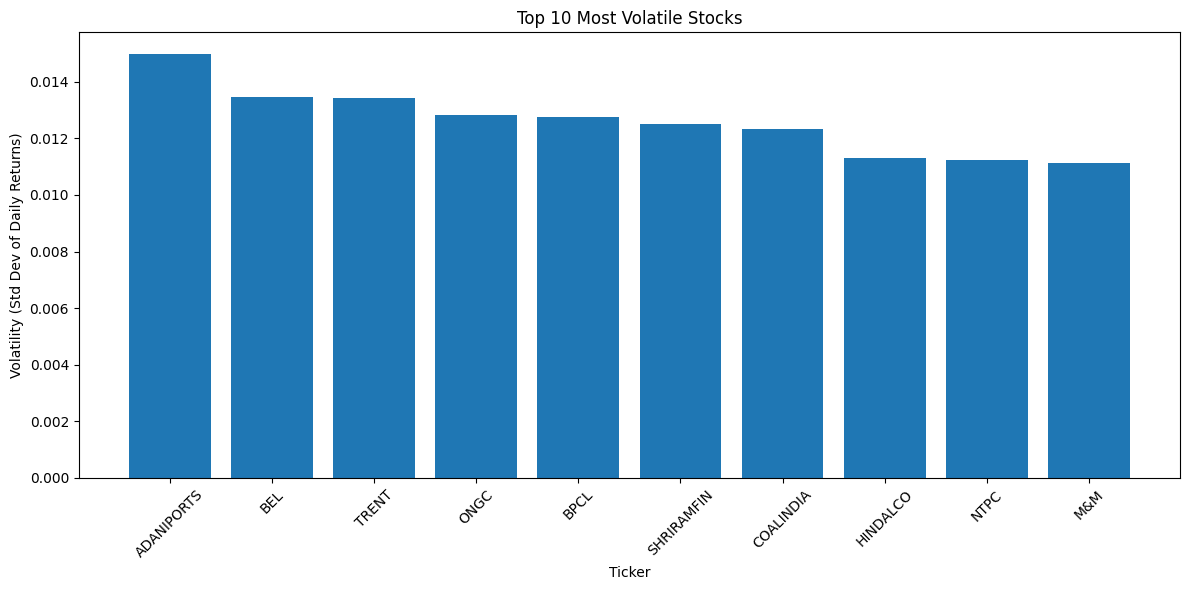

In [51]:
##1. Volatility Analysis:?
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("stock1.db")

query = """
WITH daily_returns AS (
    SELECT
        Ticker,
        date AS Date,
        (close - LAG(close) OVER (
            PARTITION BY Ticker
            ORDER BY date
        )) /
        LAG(close) OVER (
            PARTITION BY Ticker
            ORDER BY date
        ) AS daily_return
    FROM stock_data
),
stats AS (
    SELECT
        Ticker,
        AVG(daily_return) AS mean_return,
        COUNT(*) AS n
    FROM daily_returns
    WHERE daily_return IS NOT NULL
    GROUP BY Ticker
)
SELECT
    dr.Ticker,
    SQRT(
        SUM(
            (dr.daily_return - s.mean_return) *
            (dr.daily_return - s.mean_return)
        ) / s.n
    ) AS volatility
FROM daily_returns dr
JOIN stats s
    ON dr.Ticker = s.Ticker
WHERE dr.daily_return IS NOT NULL
GROUP BY dr.Ticker
ORDER BY volatility DESC
LIMIT 10;
"""

df = pd.read_sql_query(query, conn)

plt.figure(figsize=(12,6))
plt.bar(df["Ticker"], df["volatility"])
plt.title("Top 10 Most Volatile Stocks")
plt.xlabel("Ticker")
plt.ylabel("Volatility (Std Dev of Daily Returns)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

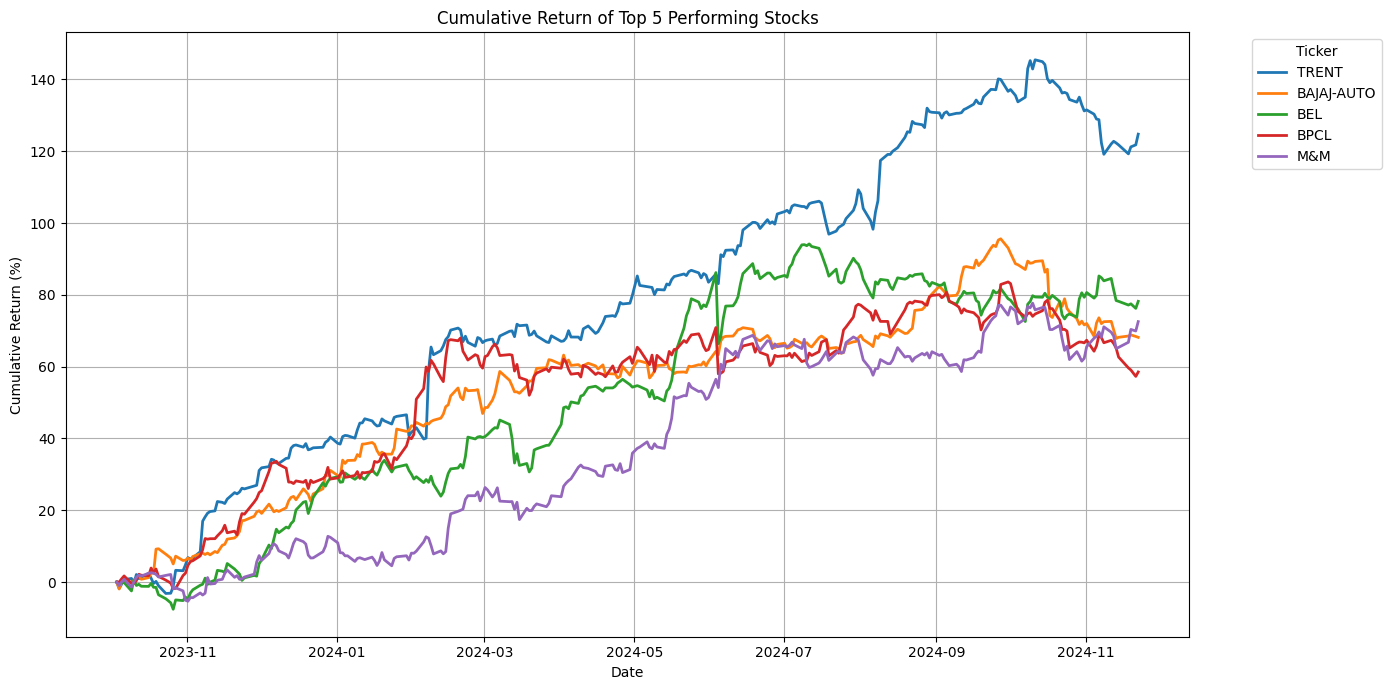

In [58]:
#2. Cumulative Return Over Time:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("stock1.db")

query = """
WITH daily_returns AS (
    SELECT
        Ticker,
        date,
        (
            (close - LAG(close) OVER (
                PARTITION BY Ticker
                ORDER BY date
            ))
            /
            LAG(close) OVER (
                PARTITION BY Ticker
                ORDER BY date
            )
        ) * 100 AS daily_return
    FROM stock_data
),

cumulative_returns AS (
    SELECT
        Ticker,
        date,
        SUM(
            COALESCE(daily_return,0)
        ) OVER (
            PARTITION BY Ticker
            ORDER BY date
        ) AS cumulative_return
    FROM daily_returns
),

top5_stocks AS (
    SELECT Ticker
    FROM (
        SELECT
            Ticker,
            MAX(cumulative_return) AS final_return,
            ROW_NUMBER() OVER (
                ORDER BY MAX(cumulative_return) DESC
            ) AS rank_num
        FROM cumulative_returns
        GROUP BY Ticker
    )
    WHERE rank_num <= 5
)

SELECT
    c.date,
    c.Ticker,
    ROUND(c.cumulative_return,2) AS cumulative_return
FROM cumulative_returns c
JOIN top5_stocks t
    ON c.Ticker = t.Ticker
ORDER BY c.date;
"""

df = pd.read_sql_query(query, conn)

conn.close()

df['date'] = pd.to_datetime(df['date'])

plt.figure(figsize=(14,7))

for ticker in df['Ticker'].unique():
    stock = df[df['Ticker'] == ticker]

    plt.plot(
        stock['date'],
        stock['cumulative_return'],
        linewidth=2,
        label=ticker
    )

plt.title(
    'Cumulative Return of Top 5 Performing Stocks'
)

plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')

plt.legend(
    title='Ticker',
    bbox_to_anchor=(1.05,1)
)

plt.grid(True)
plt.tight_layout()
plt.show()

        sector  avg_yearly_return
0    RETAILING             169.05
1      DEFENCE             160.38
2  AUTOMOBILES              94.51
3        POWER              88.77
4       MINING              87.77


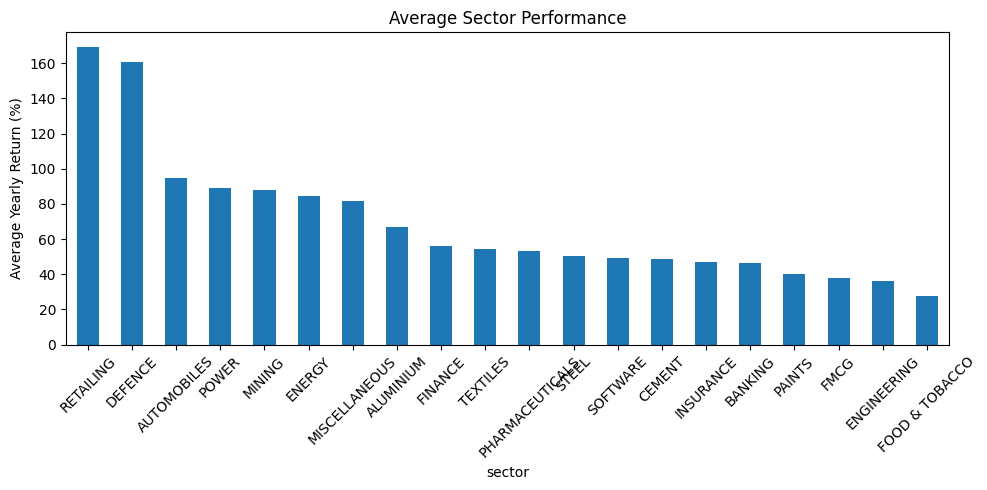

In [53]:
#3. Sector-wise Performance:?
import sqlite3
import pandas as pd

connection = sqlite3.connect('stock1.db')

query = """
WITH stock_returns AS (
    SELECT
        Ticker,
        sector,
        (
            (MAX(close) - MIN(close))
            / MIN(close)
        ) * 100 AS yearly_return
    FROM stock_data
    GROUP BY Ticker, sector
)

SELECT
    sector,
    ROUND(AVG(yearly_return), 2) AS avg_yearly_return
FROM stock_returns
GROUP BY sector
ORDER BY avg_yearly_return DESC;
"""

sector_performance_df = pd.read_sql_query(query, connection)

print(sector_performance_df.head())

connection.close()

sector_performance_df.plot(
    x='sector',
    y='avg_yearly_return',
    kind='bar',
    figsize=(10,5),
    legend=False
)

plt.ylabel('Average Yearly Return (%)')
plt.title('Average Sector Performance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

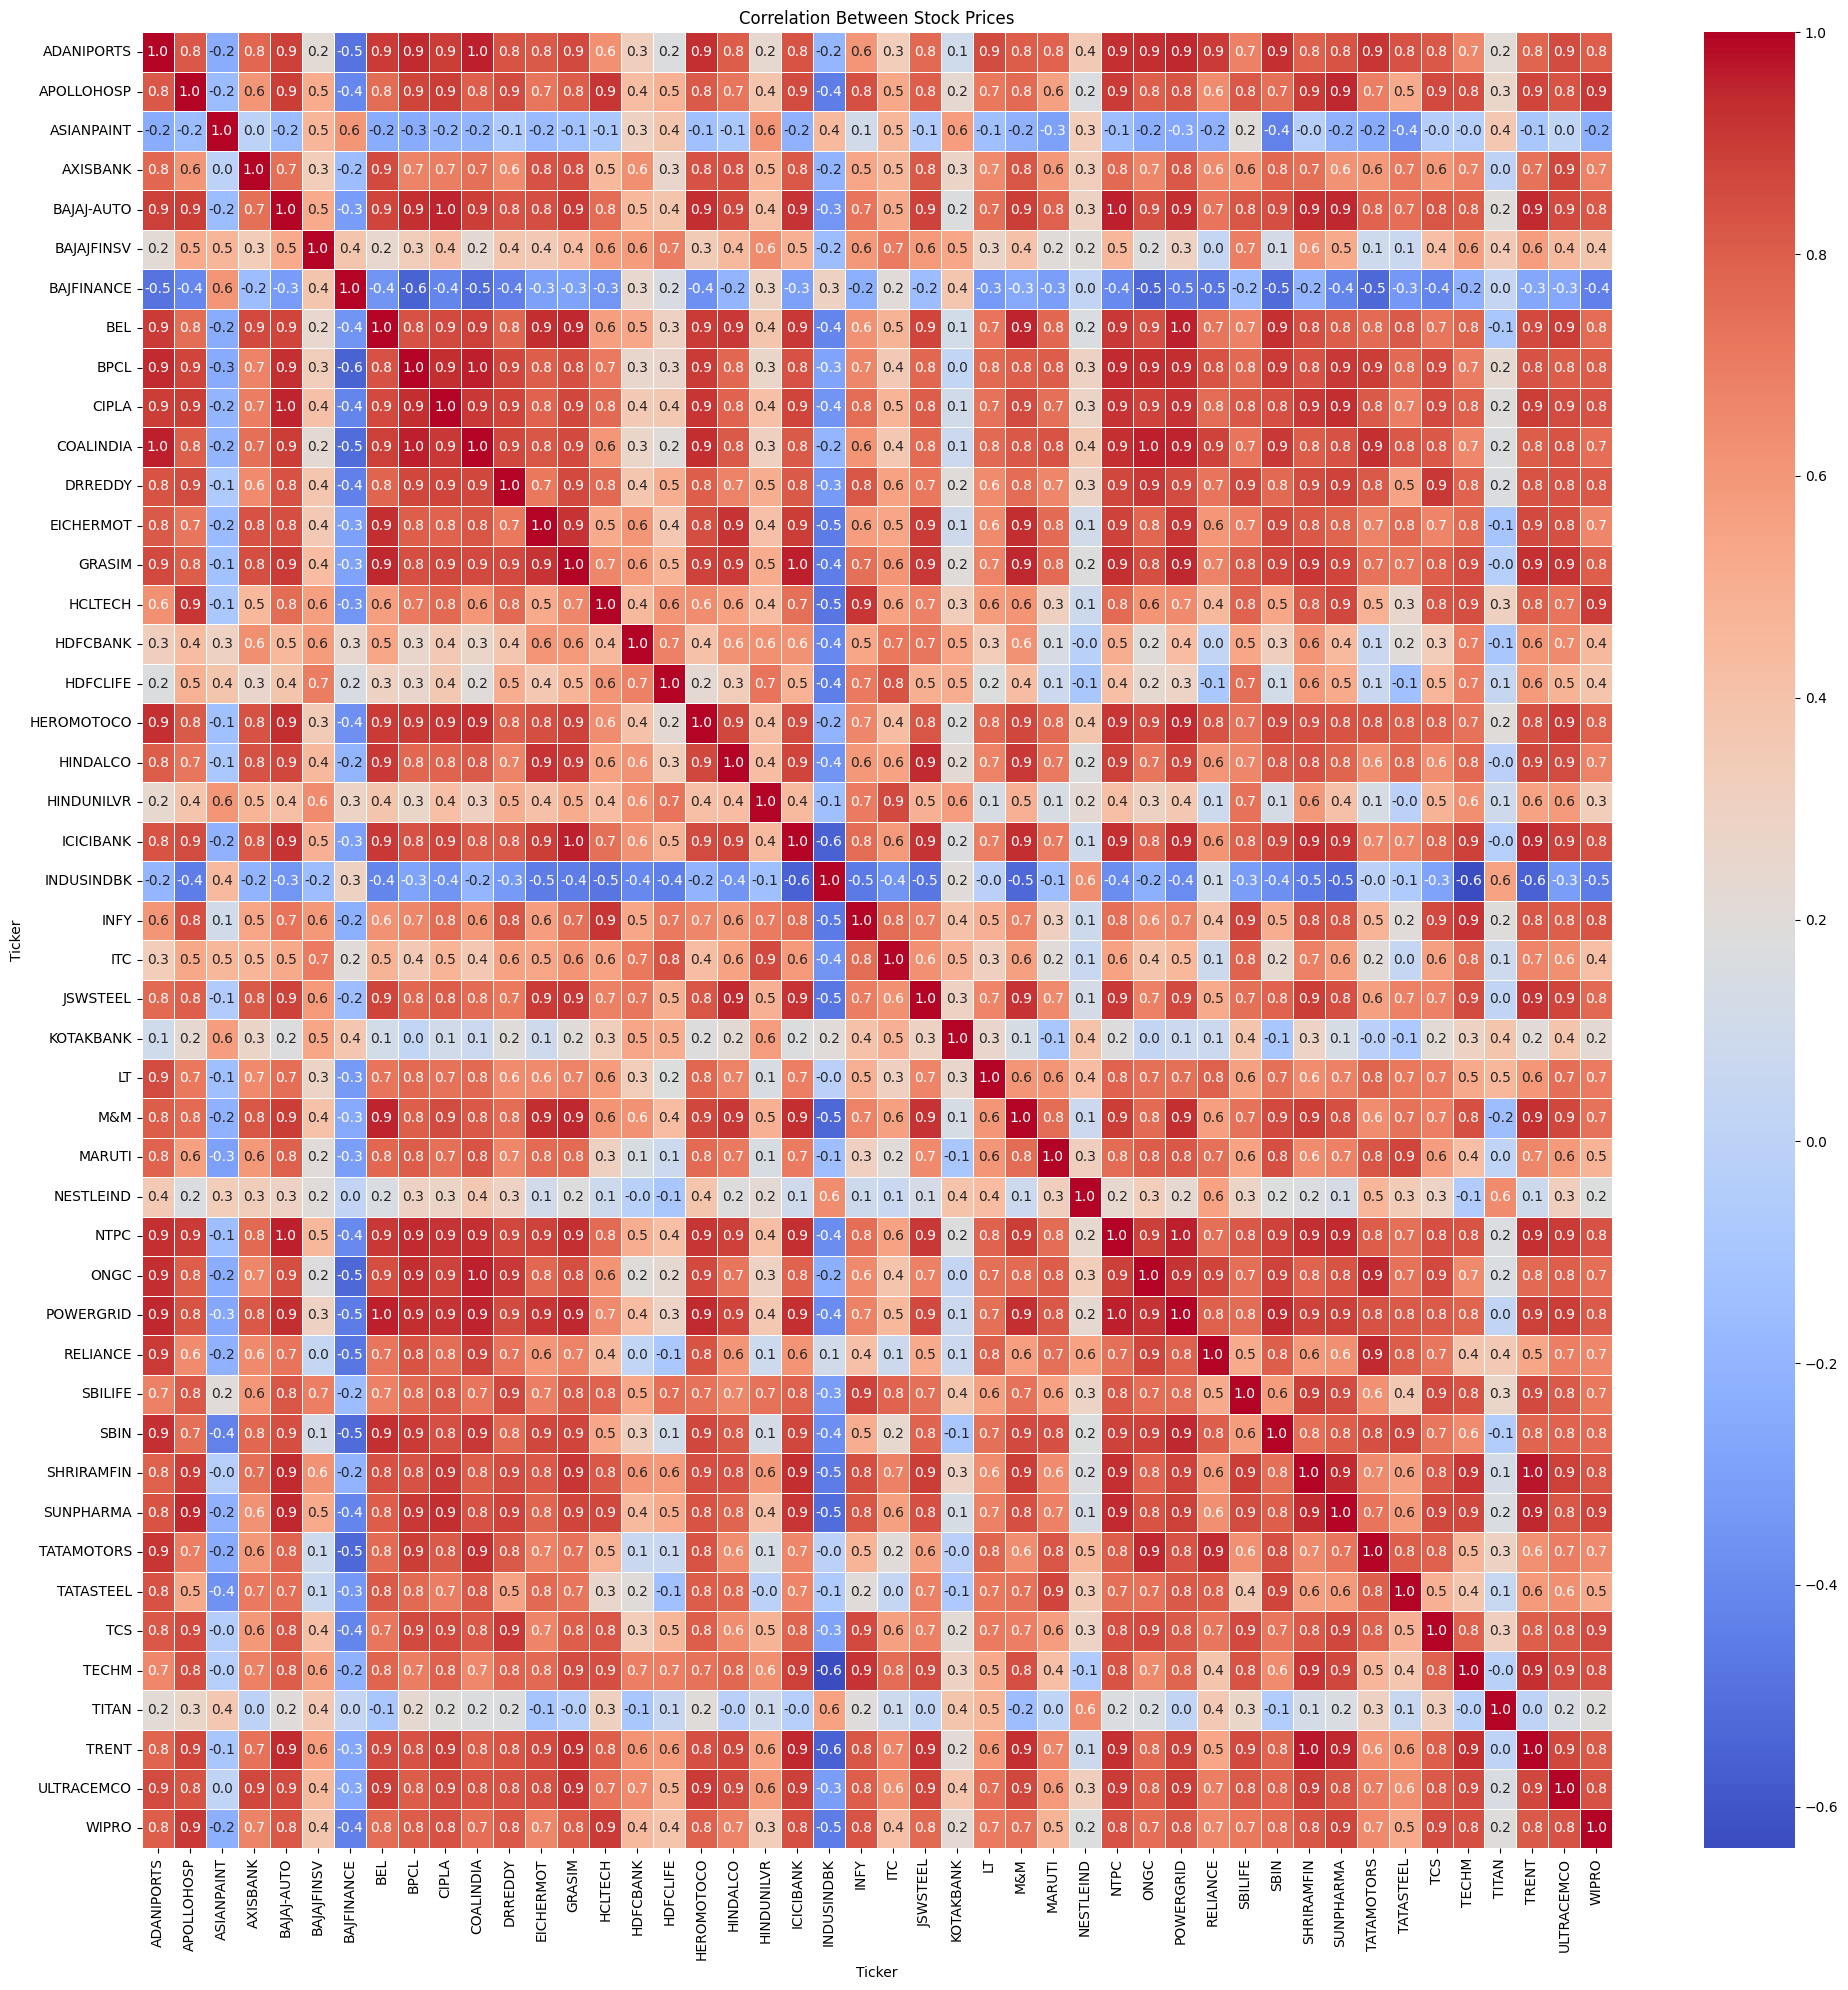

In [54]:
#4. Stock Price Correlation:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

# Read data from SQLite
conn = sqlite3.connect('stock1.db')

query = """
SELECT
    date,
    Ticker,
    close
FROM stock_data
ORDER BY date, Ticker;
"""

df = pd.read_sql_query(query, conn)

# Aggregate duplicate entries (date, Ticker) by averaging the 'close' price
df = df.groupby(['date', 'Ticker'])['close'].mean().reset_index()

# Convert rows into columns (one column per stock)
pivot_df = df.pivot(
    index='date',
    columns='Ticker',
    values='close'
)

# Correlation matrix
corr_matrix = pivot_df.corr()

# Heatmap
plt.figure(figsize=(20,20))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.1f',
    linewidths=0.5
)

plt.title('Correlation Between Stock Prices')
plt.tight_layout()
plt.show()

In [55]:
#5. Top 5 Gainers and Losers (Month-wise):
import sqlite3
import pandas as pd

connection = sqlite3.connect('stock1.db')

query = """
WITH monthly_returns AS (
    SELECT
        Ticker,
        month,
        ((MAX(close) - MIN(close)) / MIN(close)) * 100 AS monthly_return
    FROM stock_data
    GROUP BY Ticker, month
),

ranked AS (
    SELECT
        Ticker,
        month,
        ROUND(monthly_return, 2) AS monthly_return,

        ROW_NUMBER() OVER (
            PARTITION BY month
            ORDER BY monthly_return DESC
        ) AS gain_rank,

        ROW_NUMBER() OVER (
            PARTITION BY month
            ORDER BY monthly_return ASC
        ) AS loss_rank

    FROM monthly_returns
)

SELECT
    month,
    Ticker,
    monthly_return,
    'Top Gainer' AS category
FROM ranked
WHERE gain_rank <= 5

UNION ALL

SELECT
    month,
    Ticker,
    monthly_return,
    'Top Loser' AS category
FROM ranked
WHERE loss_rank <= 5

ORDER BY month, category, monthly_return DESC;
"""

top_monthly_performers_df = pd.read_sql_query(query, connection)

#print(top_monthly_performers_df.head())
gainers = top_monthly_performers_df[top_monthly_performers_df['category'] == 'Top Gainer']
losers = top_monthly_performers_df[top_monthly_performers_df['category'] == 'Top Loser']
print('Top 5 Gainers:')
print(gainers.head())
print('\nTop 5 Losers:')
print(losers.head())
connection.close()

Top 5 Gainers:
     month      Ticker  monthly_return    category
0  2023-10  BAJAJ-AUTO           11.60  Top Gainer
1  2023-10       WIPRO           11.34  Top Gainer
2  2023-10  HEROMOTOCO           10.52  Top Gainer
3  2023-10       TECHM           10.41  Top Gainer
4  2023-10   COALINDIA           10.28  Top Gainer

Top 5 Losers:
     month      Ticker  monthly_return   category
5  2023-10  INDUSINDBK            4.84  Top Loser
6  2023-10   KOTAKBANK            4.53  Top Loser
7  2023-10        ONGC            4.37  Top Loser
8  2023-10     HCLTECH            4.36  Top Loser
9  2023-10  HINDUNILVR            4.07  Top Loser


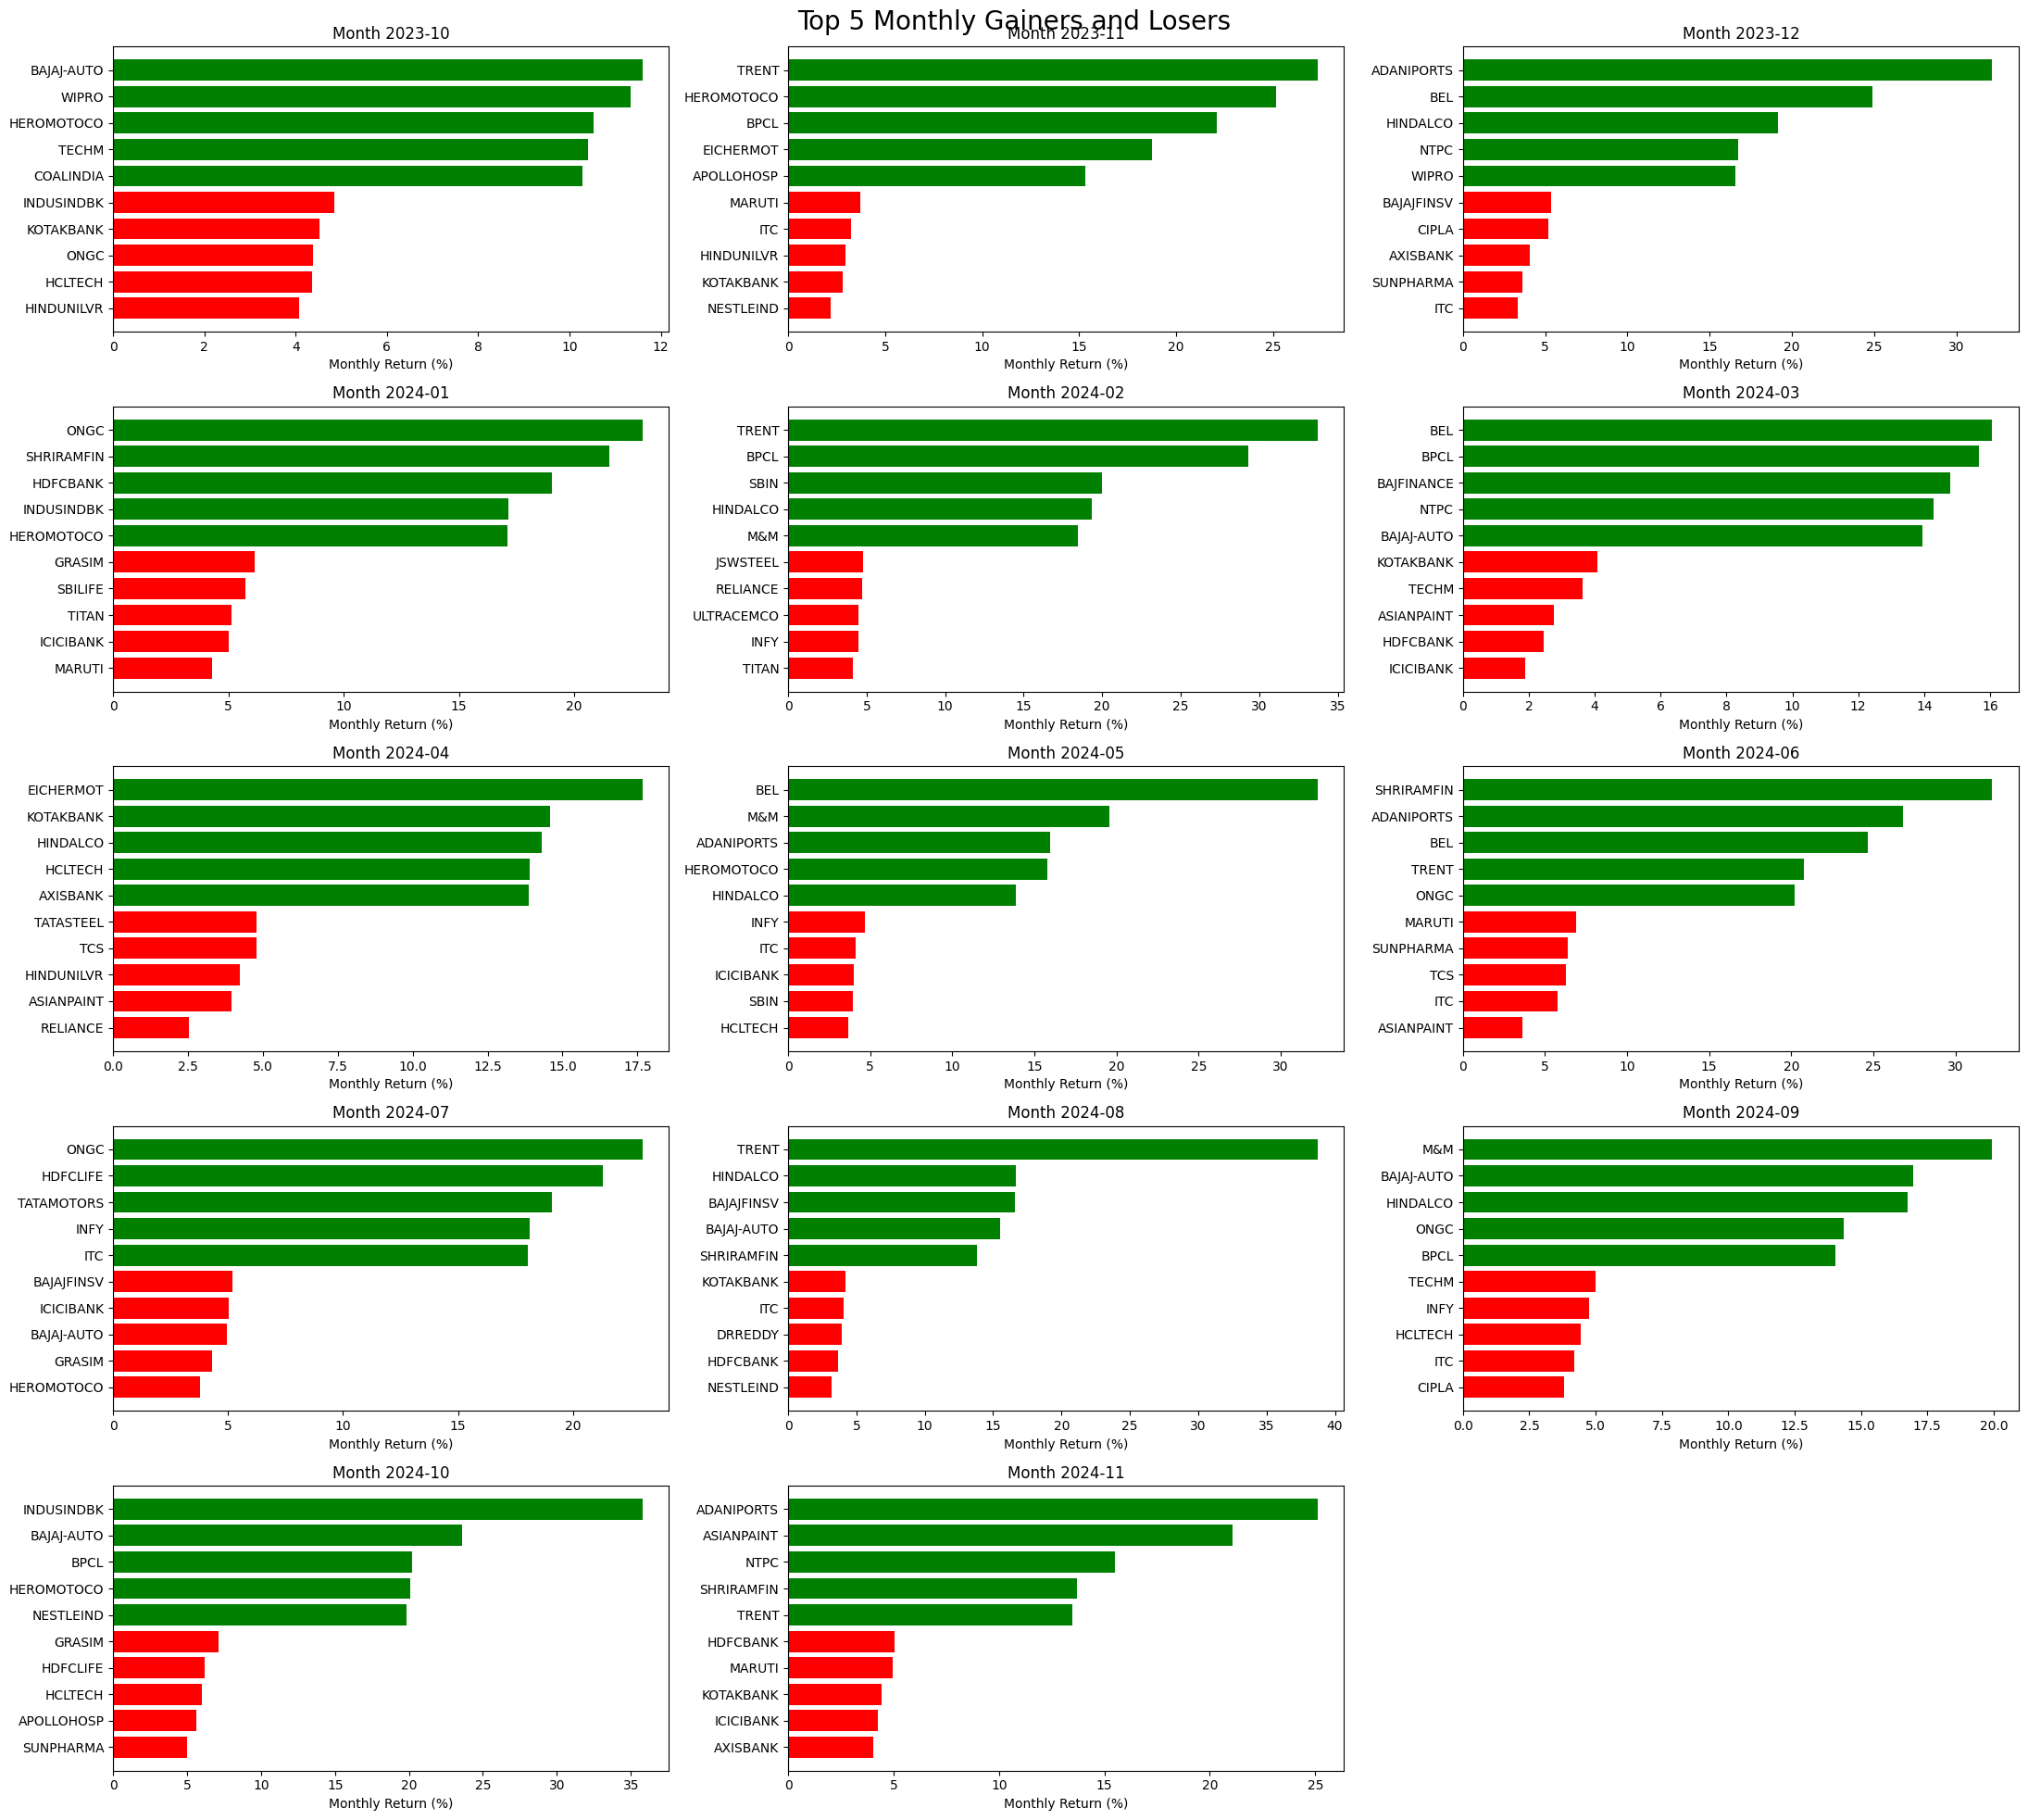

In [57]:
import matplotlib.pyplot as plt

months = sorted(top_monthly_performers_df['month'].unique())

num_months = len(months)
num_cols = 3
num_rows = (num_months + num_cols - 1) // num_cols # Calculate rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(22, 4 * num_rows)) # Adjust figsize accordingly
axes = axes.flatten()

for i, month in enumerate(months):

    ax = axes[i]

    gainers = top_monthly_performers_df[
        (top_monthly_performers_df['month'] == month) &
        (top_monthly_performers_df['category'] == 'Top Gainer')
    ].sort_values('monthly_return', ascending=True)

    losers = top_monthly_performers_df[
        (top_monthly_performers_df['month'] == month) &
        (top_monthly_performers_df['category'] == 'Top Loser')
    ].sort_values('monthly_return')

    combined = pd.concat([losers, gainers])

    colors = ['red'] * len(losers) + ['green'] * len(gainers)

    ax.barh(
        combined['Ticker'],
        combined['monthly_return'],
        color=colors
    )

    ax.axvline(0, color='black', linestyle='--')

    ax.set_title(f'Month {month}')
    ax.set_xlabel('Monthly Return (%)')

for j in range(len(months), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Top 5 Monthly Gainers and Losers', fontsize=20)
plt.tight_layout()
plt.show()